# Where the Water Flows -- Glacier de Bonne Pierre

In [68]:
using Pkg; Pkg.activate("/scratch-1/cogier/hydraulic_barriers/")
Pkg.resolve()
using Rasters
using Shapefile
using WhereTheWaterFlowsSubglacially, WhereTheWaterFlows
const WWFS = WhereTheWaterFlowsSubglacially
const WWF = WhereTheWaterFlows
using ArchGDAL
#using MAT
using Plots
using GlacioTools
include("/scratch-3/cogier/GlacioTools.jl/src/Rasters_helpers.jl")
#using GLMakie
#Pkg.status()



  Activating project at `/scratch-1/cogier/hydraulic_barriers`
  No Changes to `/scratch-1/cogier/hydraulic_barriers/Project.toml`
  No Changes to `/scratch-1/cogier/hydraulic_barriers/Manifest.toml`


assert_Point

In [8]:
datadir = "/scratch-3/cogier/data/DEM"
#include("helper_functions.jl")

"/scratch-3/cogier/data/DEM"

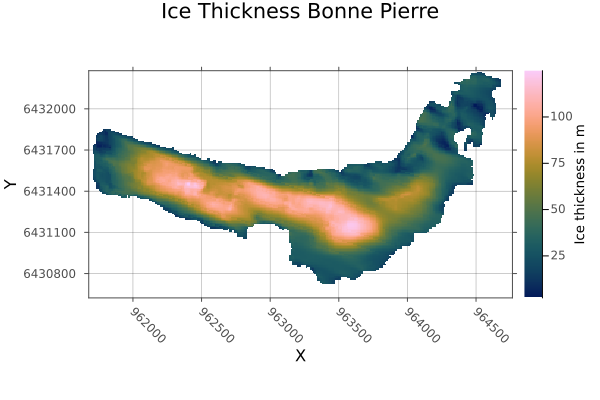

In [9]:
# Bonne Pierre
ice_thickness = Raster(joinpath(datadir,"IceThickness_BP_2024.tif"));
bed = Raster(joinpath(datadir,"Bedrock_BP_2024.tif"));
Plots.heatmap(ice_thickness,title="Ice Thickness Bonne Pierre", 
colorbar_title="Ice thickness in m")

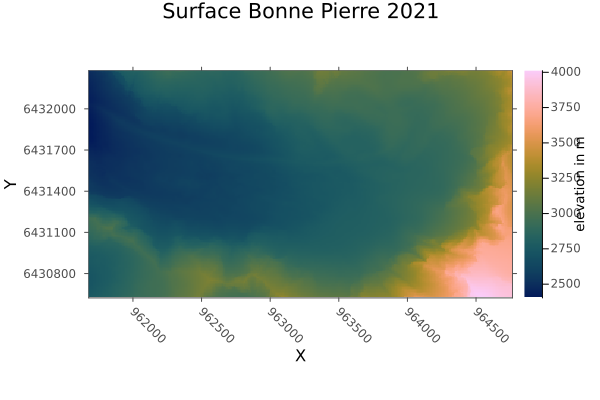

In [287]:

# Surface DEM = IceThickness + Bedrock
surface_nov_2024 = bed + ice_thickness;

# Clip the  2021 surface raster to the extent of the bedrock raster
all_surf_2021 = Raster(joinpath(datadir,"Berarde_Res1.0_CompElevmean_merged.tif"));
surface_2021 = crop(all_surf_2021; to=bed)
# resample DEM
surface_2021_resamp = resample(surface_2021; to=bed)
# plot
Plots.heatmap(surface_2021_resamp,title="Surface Bonne Pierre 2021", 
colorbar_title="elevation in m")

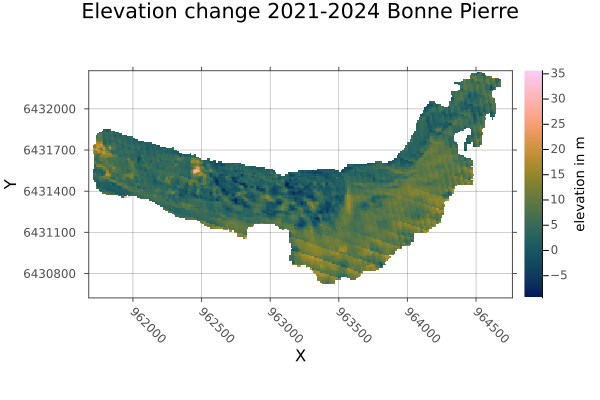

In [288]:
# difference surface 2021 and 2024

Plots.heatmap(surface_2021_resamp - surface_nov_2024,title="Elevation change 2021-2024 Bonne Pierre", 
colorbar_title="elevation in m")

In [289]:
# ahndling missing
bed = replace(bed, missing => NaN);
surface_2021_resamp = replace(surface_2021_resamp, missing => NaN);
surface_nov_2024 = replace(surface_nov_2024, missing => NaN);

In [290]:
x,y = dims(bed)


(↓ X Projected{Float64} 961677.8660997689:10.683080483054962:964754.5932788887 ForwardOrdered Regular Intervals{Start},
→ Y Projected{Float64} 6.432267606134425e6:-10.683080483052589:6.430622411740035e6 ReverseOrdered Regular Intervals{Start})

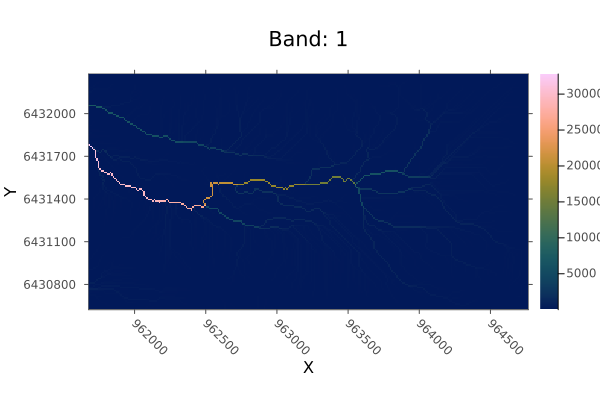

In [291]:
area, slen, dir, nout, nin, sinks, pits, c, bnds = WWF.waterflows(surface_2021_resamp);
#plt_area(area, pits)
heatmap(area)

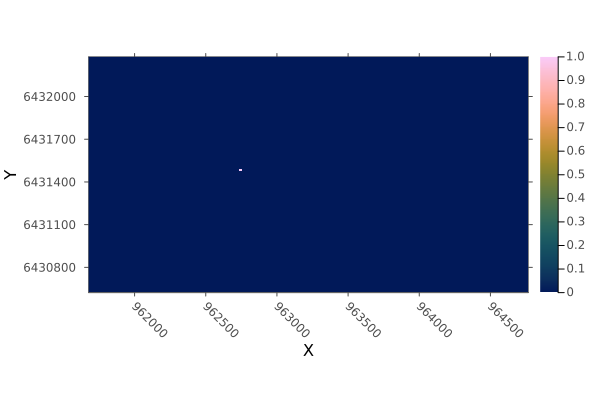

In [292]:
# A single catchment of some point.  Choose one with large catchment:
i, j = 100, 75
cc = catchment(dir, CartesianIndex(i,j))
heatmap(cc)
#scatter!(x[i], y[j], markersize=50)

In [293]:
## convert DEM in matric
typeof(bed[:,:,1])
dx = x[2] - x[1]

10.683080483111553

In [294]:

# Gamma is the Rothlisberger constant. [1] is without gamma, [2] is gamma=WWFS.GAMMA = -0.31 (Rothlisberger constant = stream deflection)

#surface 2021
(area_2021, slen_2021, dir, nout, nin, pits, c, bnds),
         (sc_locs, kappas, diro, phi_2021),
         (lakes, lakes_free_surf_2021),
         sinkout = WWFS.waterflows_subglacial(surface_2021_resamp, bed, dx, gamma=[0,WWFS.GAMMA][2], bnd_as_sink=true, drain_pits=true);

#surface 2024
(area_2024, slen_2024, dir, nout, nin, pits, c, bnds),
(sc_locs, kappas, diro, phi_2024),
(lakes, lakes_free_surf_2024),
sinkout = WWFS.waterflows_subglacial(surface_nov_2024, bed, dx, gamma=[0,WWFS.GAMMA][2], bnd_as_sink=true, drain_pits=true);

#area -- upslope area, tuple containing: total flux (m3/s), extra flux (m3/s), dissipation-melt-rate (m/s), pressure-melt-rate (m/s)



         

((area = ([NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN], [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN]), slen = [0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], dir = Int8[11 11 … 11 11; 11 11 … 11 11; … ; 11 11 … 11 11; 11 11 … 11 11], nout = Bool[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], nin = Int8[0 0 … 0 0; 0 0 … 0 0; … ; 0 0 … 0 0; 0 0 … 0 0], sinks = CartesianIndex{2}[CartesianIndex(266, 2), CartesianIndex(267, 2), CartesianIndex(268, 2), CartesianIndex(262, 3), CartesianIndex(263, 3), CartesianIndex(264, 3), CartesianIndex(265, 3), CartesianIndex(266, 3), CartesianIndex(268, 3), CartesianIndex(269, 3)  …  CartesianIndex(168, 145), CartesianIndex(160, 146), CartesianIndex(161, 146), CartesianIndex(162, 146), CartesianIndex(163, 146), Cartesia

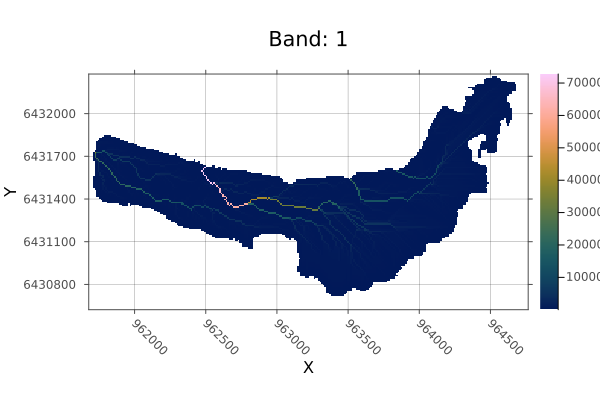

In [286]:
Plots.heatmap(slen_2021,title="")
typeof(area_2021)
heatmap(area_2021[1])





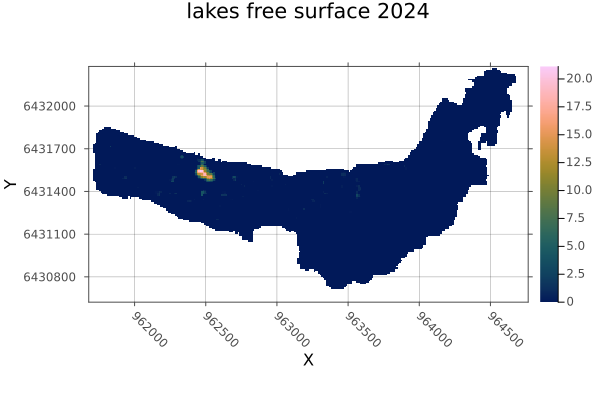

In [216]:
Plots.heatmap!(lakes_free_surf_2024,title="lakes free surface 2024")

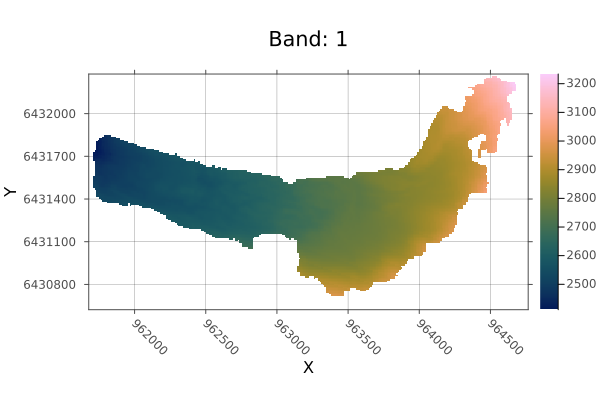

In [206]:
Plots.heatmap(phi)

In [273]:
#WRITE
write(joinpath(datadir,"lakes_free_surf_2021_BP.tif"),lakes_free_surf_2021,force=true);
write(joinpath(datadir,"phi_2021_BP.tif"),phi_2021,force=true);
write(joinpath(datadir,"lakes_free_surf_2024_BP.tif"),lakes_free_surf_2024,force=true);
write(joinpath(datadir,"phi_2024_BP.tif"),phi_2024,force=true);
write(joinpath(datadir,"area_2024_BP.tif"),area_2024[1],force=true);  
write(joinpath(datadir,"area_2021_BP.tif"),area_2021[1],force=true);


In [ ]:
# Findelen surface in 1931
surf_findelen_1931 = Raster(joinpath(datadir,"alps/findelen_1931_25m_lv95.tif"));
Plots.heatmap(surf_findelen_1931)

In [ ]:
# bedrock of findelen 2016
#geom_select("Findelen","B56-03", datadir, do_save=true); 
findelen_BedElev_2016 = Raster(joinpath(datadir,"alps/Findelen_BedElev_cr.tif"));

In [ ]:
# Merge bed rock of 2016 and surface elevation 2019 -> that makes glacier free topography ONLY for findelen though
all_bed_findelen = mosaic(first, findelen_BedElev_2016, all_surf_2019);  # in case of overlap, we take the values of all_bed first

In [ ]:
Plots.heatmap(all_bed_findelen)

In [ ]:
#crop surface elevation to bed data to match dimension (before substracting)
bed_findelen_1931_cr = crop(all_bed_findelen; to=surf_findelen_1931);
bed_findelen_1931_cr[bed_findelen_1931_cr .< 0] .= NaN; #missing values in all_surf is -3.4028235e38
Plots.heatmap(bed_findelen_1931_cr)

In [ ]:
Plots.heatmap(surf_findelen_1931)

In [ ]:
bed_findelen_1931_cr_resamp = resample(bed_findelen_1931_cr, to=surf_findelen_1931)

In [ ]:
size(surf_findelen_1931) == size(bed_findelen_1931_cr_resamp)

In [ ]:
write(joinpath(datadir,"alps","Findelen_bed_1931_25m.tif"),bed_findelen_1931_cr_resamp);

In [ ]:
# with gamma = -0.31 (Rothlisberger constant = stream deflection)
(area_r, slen_r, dir, nout_r, nin_r, pits_r, c_r, bnds_r),
         (sc_locs_r, kappas_r, diro_r, phi_r),
         (lakes_r, lakes_free_surf_r),
         sinkout_r = WWFS.waterflows_subglacial(surf_findelen_1931[:,:,1], bed_findelen_1931_cr_resamp[:, :, 1], gamma=[0,WWFS.GAMMA][2], bnd_as_pits=true, drain_pits=true);

In [ ]:
write(joinpath(datadir,"WWFS_output","area_r_findelen1931.tif"),area_r);
write(joinpath(datadir,"WWFS_output","lakes_r_findelen1931.tif"),lakes_r);
write(joinpath(datadir,"WWFS_output","phi_r_findelen1931.tif"),phi_r); # shreve potential
